## Neural Machine Translation

Machine translation is the task of translating a sentence(x) present in one language to a sentence(y) in another language.

Neural machine translation is a classic example of a sequence‑to‑sequence (seq2seq) problem. In this setting, the input and output sequences usually have different lengths, unlike the many‑to‑many RNNs seen in basic sequence tasks.



### History

**1940s-1980s: Rule-Based Machine Translation (RBMT)**

**Idea:** Warren Weaver (1949) proposed computers could translate languages.

**How it worked:**
```
Step 1: Parse source sentence → grammar trees
Step 2: Map to target grammar → dictionary lookup  
Step 3: Generate target sentence → apply rules
```

**Example:** English "The cat sleeps" → Spanish "El gato duerme"
```
English grammar: Article-Noun-Verb
Spanish grammar: Article-Noun-Verb ✓
Dictionary: cat→gato, sleeps→duerme
```

**Problems:**
- Thousands of hand-written rules
- Failed on complex sentences/idioms
- Language-pair specific (English→Spanish ≠ English→Telugu)

**Analogy:** Like following a cooking recipe step-by-step, but recipes don't exist for every possible dish variation.

**1990s-2010s: Statistical Machine Translation (SMT)**

**Breakthrough:** Computers learned translation probabilities from **parallel corpora** (sentence pairs).

**Core idea:** Find statistically most likely translation:
```
P(translation | source) = P(source | translation) × P(translation)
```

**How Google Translate worked (pre-2016):**
```
Input: "I love programming"
Corpus has 1M sentence pairs
Model finds: "Me encanta programar" appears 5K times with this English
             Other Spanish options appear less frequently
Output: "Me encanta programar" ✓
```

**Advantages over RBMT:**
- Data-driven (no hand-written rules)
- Handles unknown words via probabilities
- Scales with more data

**Limitations:**
- Word-by-word alignment (ignores sentence context)
- N-gram models forget long-range dependencies
- "The translation is fluent but makes no sense"

**Analogy:** Like translating by copying the most popular recipe version, but not understanding why ingredients work together.

**2000s: Neural Language Foundations**

**Yoshua Bengio's contribution (2003):** Invented **neural language models**.

**Key insight:** Instead of counting word frequencies, use **distributed representations** (word embeddings).

```
Traditional: "cat" = ID 5234 (one-hot)
Neural:      "cat" = [0.2, -0.1, 0.8, ...] (300-dim vector)

"cat" ≈ "dog" ≈ "kitten" in vector space ✓
```

This laid groundwork: **Neural networks understand language relationships**, not just statistics.

**2014: Seq2Seq Revolution (Neural Machine Translation)**

**Papers:** Sutskever et al. & Cho et al. (both 2014)

**Architecture:** **Encoder-Decoder LSTM**

```
Input:  "I love programming"  (Tx=3 words)
↓ Encoder LSTM
Context: [0.23, -0.45, 0.67, ...]  (fixed 512-dim vector)
↓ Decoder LSTM  
Output: "Me encanta programar"     (Ty=3 words)
```

**Why it works:**

1. **Encoder:** Reads entire source → compresses to "thought vector"
2. **Decoder:** Unpacks thought vector → generates target word-by-word

```
Unlike SMT (word-by-word): Seq2seq understands FULL SENTENCE CONTEXT
"I saw the man with the telescope" → Correct Spanish translation ✓
```

**End-to-End Learning:** Single neural network learns **everything** (no rules, no phrase tables).


```
1949: Weaver's dream → RBMT (rules + dictionaries)
1990s: SMT (statistics from parallel data)
2003: Bengio (neural language models)
2014: Seq2Seq LSTM → Modern NMT (Google Translate 2016+)
```

```
Variable input length → Fixed context vector → Variable output length
     Tx=15 words              512-dim              Ty=12 words
```

**Analogy:** Encoder = "summarize entire book into 1 page notes" → Decoder = "write new book from notes"

### Statistical Machine Translation (SMT)
- How Google Translate Worked (1990s-2015)

SMT was the dominant approach before neural networks. It finds the **best translation** using probability math from parallel sentence data.

**Bayes' Rule**

```
Given source sentence x, find best target y:
ˆy = argmax P(y | x) = argmax P(x | y) × P(y)
         y                  y

P(x | y) = Translation Model (how well y explains x)
P(y)     = Language Model (how fluent is y?)
```

**Intuition:** Best translation = (most likely given source) × (most fluent target)

**1. Translation Model: P(x | y)**
**Job:** "How likely is this source sentence to come from this target translation?"

```
Example: English "I eat apple" → Telugu "నేను ఆపిల్ తింటాను"

Translation Model learns from parallel
P("నేను" | "I") = 0.95    (I → నేను 95% of time)
P("తింటాను" | "eat") = 0.88
P("ఆపిల్" | "apple") = 0.92

Score: 0.95 × 0.88 × 0.92 = 0.77 ✓
```

**Data:** Parallel corpora (aligned sentence pairs)
**Learned:** Word/phrase alignment probabilities

**Analogy:** Dictionary + "how often does word A translate to word B?"

**2. Language Model: P(y)**
**Job:** "Does this target sentence sound natural?"

```
Bad: "I apple eat" → P=0.001 (ungrammatical)
Good: "I eat apple" → P=0.85 (grammatical)

n-gram LM: P(word_t | word_{t-n+1} ... word_{t-1})
P(eat | I) × P(apple | I eat) = High score ✓
```

**Data:** Monolingual target language corpus (billions of sentences)
**Method:** n-gram counts (trigrams, 4-grams, etc.)

**Analogy:** Grammar/spelling checker for target language

**How They Work Together**

```
Input: "The cat sleeps"

1. Translation Model generates candidates:
   Candidate 1: "El gato duerme" → P(x|y)=0.92
   Candidate 2: "La casa grande" → P(x|y)=0.15

2. Language Model scores fluency:
   Candidate 1: P(y)=0.88 (natural Spanish)
   Candidate 2: P(y)=0.45 (odd Spanish)

3. Final score: P(x|y) × P(y)
   Candidate 1: 0.92 × 0.88 = 0.81 ✓ WINNER
   Candidate 2: 0.15 × 0.45 = 0.07
```

**Search Algorithm (Decoder)**

**Problem:** Can't check all possible translations (10^20+ possibilities)

**Solution:** **Beam search** - keep top-K most probable partial translations

### Why Sequence to Sequence models?

Seq2seq architectures address the core problem in NMT: mapping an input sequence of length $T_x$ to an output sequence of length $T_y$, where $T_x \ne T_y$.

In machine translation, **the number of words in the source and target sentences typically differs, even when they express the same meaning.**
- For example, “I am studying artificial intelligence.” and “Estoy estudiando inteligencia artificial.” contain **different word counts and structures, despite being translations of each other**.

Standard RNNs (or LSTMs/GRUs) used for sequence labeling produce one hidden state and one output per input timestep, so the output length always matches the input length. That is suitable for tasks like POS tagging, but not for translation, where the target sequence length is generally not equal to the source sequence length.
- This violates the assumption of `one output per input timestep` that standard RNN setups implicitly rely on.
- Seq2seq architectures were introduced to solve precisely this mismatch between input length $T_x$ and output length $T_y$.

Sequence to sequence models use a **dual‑RNN design**: an encoder and a decoder.
- The encoder consumes the entire input sentence and compresses it into a single fixed‑size vector often called a `thought vector` or `context vector`.
  - the encoder “folds” the input sequence into a compact but informative vector
- The decoder takes this vector and **generates the target sentence, one token at a time**.
  - the decoder “unfolds” that vector into a new sequence.
- This encoder–decoder pattern is a recurring idea in deep learning, where **complex inputs are compressed into a compact representation and then reconstructed or transformed.**
  - It captures how the model moves from raw text to a high‑level representation and then back to text in another language.

### Encoder: From Sequence to Thought Vector

The encoder is typically an RNN (LSTM or GRU) that **processes the source sentence token by token**.

- The encoder reads the input sequence $(x_1, x_2, \dots, x_{T_x})$ and produces a sequence of hidden states $(h_1, h_2, \dots, h_{T_x})$.  
- In the basic encoder decoder formulation, only the **final** hidden state $h_{T_x}$ is kept as the sentence representation.  
  - With an **LSTM, both the final hidden state $h_{T_x}$ and the cell state $c_{T_x}$ are retained**; with a GRU, only $h_{T_x}$ is needed.

When implementing this, the encoder RNN is configured with `return_sequences=False` so that it outputs a single vector rather than the full sequence of intermediate states. The result is a fixed‑dimensional vector of size $M$, independent of the input length.
- **This vector does not explicitly preserve time information; instead, it is a compressed summary of the entire sentence’s semantics.**

### Decoder: From Thought Vector to Target Sequence

The decoder is a second RNN, with its own parameters, but its hidden state dimensionality must match the encoder’s vector size $M$. This is necessary because the decoder’s initial hidden state is set equal to the encoder’s final state. In other words, the decoder is `initialized` with the encoded representation of the source sentence.

**At the first decoding timestep:**

- The initial hidden state $h_0^{\text{dec}}$ is set to the encoder’s final state (for an LSTM, both $h_{T_x}$ and $c_{T_x}$ are used as initial states).  
- The input token is a special `<start-of-sentence>` symbol, usually written `<SOS>` or similar, which is prepended to all target sequences during training.

**From this, the decoder produces:**

- A new hidden state $h_1^{\text{dec}}$.  
- A probability distribution $y_1$ over the target vocabulary via a Dense (softmax) layer applied to the hidden state. The Dense layer output size equals the target vocabulary size $V$.

**At subsequent timesteps, decoding becomes autoregressive:**

- The input at step 2 is the previously generated word. That is, the predicted token at step 1 (e.g., argmax($y_{1}$)) becomes the decoder input $x_2^{\text{dec}}$.  
- This pattern repeats: $y_1$ feeds $x_2^{\text{dec}}$, $y_2$ feeds $x_3^{\text{dec}}$, and so on, generating a sequence until an `<end-of-sentence>` token is produced or a maximum length is reached.

This mechanism is exactly the same as **neural language generation**: the model conditions on past outputs (and the initial context from the encoder) to produce the next word. Language modeling is a canonical example of this `feed your last prediction as the next input` pattern.

#### How is decoder connected to Language Modeling?

The decoder RNN with its **softmax output implements a conditional language model over the target language**, conditioned on the source sentence via the encoder state.
- At each step, it models $p(y_t \mid y_{<t}, \text{source})$. Structurally, this is the same as language modelling, **except that the initial hidden state encodes the source sentence.**
- Because the **decoder repeatedly uses its own outputs as inputs, it can generate sequences of arbitrary length and is not constrained to produce the same number of tokens as the encoder consumed.**
- This is precisely what allows seq2seq models to handle input and output sequences with different lengths.

## Applications of Encoder decoder models

Encoder decoder models are not limited to machine translation. Many other tasks share the same `input sequence → output sequence` structure and can reuse the same architecture.

Some problems naturally look like `source sentence → target sentence,` even if they are not literal language translation. In these cases, the model reads an input sequence, compresses it into a thought vector via an encoder, and then decodes that vector into a target sequence.

Typical examples include:

- Machine translation: Source sentence in language A → translated sentence in language B.  
- Question answering (reading comprehension style): Story + question → answer span or short phrase.  
- Chatbots (request–response pairs): User message → bot response.

In all of these, the data can be organized as aligned pairs: an input sequence of tokens and a corresponding output sequence of tokens. Training then consists of teaching the neural network to map each input sequence to its target output sequence, just as in translation.

### Requirements of NMT Model

NMT systems must solve 4 fundamental challenges that previous approaches (RBMT, SMT) struggled with.

**1. Variable Length Sequences**

**Problem:** Input ≠ Output length
```
English: "I love programming" (3 words)
Spanish: "Me encanta programar" (3 words) ✓
German:  "Ich liebe das Programmieren" (4 words) ✗
```

**Solution:** Encoder-decoder architecture
```
Encoder: Variable Tx → Fixed context vector (512-dim)
Decoder: Fixed context → Variable Ty ✓
```

**Why RNN/LSTM:** Handles arbitrary sequence lengths dynamically.

**2. Correct Information Order (Sequential Processing)**

**Problem:** Words depend on position/context
```
"I saw the man with the telescope"
vs "I saw the man with the telescope"
```

**Solution:** RNNs process **left-to-right** (forward) + hidden state carries context
```
t=1: "I" → h₁
t=2: "saw" + h₁ → h₂  
t=3: "the" + h₂ → h₃
...
Decoder uses h_T (full context) ✓
```

**Key:** Hidden state $h_t$ encodes **all previous information** in order.

**3. Parameter Sharing Across Sequences**

**Problem:** Different model per sentence length = impossible

**Solution:** **Same weights** for every timestep
```
LSTM weights W are FIXED across all t:
h_t = LSTM(x_t, h_{t-1}; W)  # Same W for t=1,2,3,...

No matter if Tx=5 or Tx=50 → Same model ✓
```

**Advantage:** Learns **general rules**, not sentence-specific patterns.

```
Weight tying = "One model rules them all"
```

**4. Long-Term Dependencies**

**Problem:** Vanilla RNN forgets distant context
```
"I grew up in France... I speak fluent French"
Encoder must remember "France" when predicting "French" ✓
```

**Solution:** LSTM/GRU gates preserve long-range info
```
LSTM gates:
Forget gate → Discard irrelevant info
Input gate  → Add new relevant info  
Output gate → Expose relevant info

h_50 remembers important info from t=1 ✓
```

## Decoder Training: Language Modeling

Language modeling provides the exact code template needed for decoder training. Language modeling learns $p(w_t \mid w_{<t})$: **predict the next word given all previous words in the sequence.** Once trained, new text is generated by sampling from this distribution iteratively.

```
Core idea: Next-word prediction → Autoregressive generation
```

Training data uses teacher forcing with explicit start/end tokens:

```
Input sequence:
<SOS>  The  quick  brown  fox.

Target sequence:  
       The  quick  brown  fox.  <EOS>
```

**Key properties:**
- Both sequences have identical length $T$
- Target = Input shifted right by 1 position
- `<SOS>` starts input; `<EOS>` ends target
- At timestep $t$, model predicts $w_t$ from $w_{<t}$

This teaches the RNN to condition on prefix history for next-word prediction.

This data layout is **identical** to seq2seq decoder training with teacher forcing:

```
Seq2seq decoder training:
Input:  <SOS> y₁ y₂ ... y_{T-1}
Target:       y₁ y₂ ... y_T <EOS>

Language model training:  
Input:  <SOS> w₁ w₂ ... w_{T-1}  
Target:       w₁ w₂ ... w_T <EOS>
```

**Single difference:** Initial hidden state source

| Language Model | Seq2seq Decoder |
|----------------|-----------------|
| $h_0 =$ zeros or learned | $h_0 =$ encoder final state |
| No source context | Source encoded as context |

### Keras and fixed sequence lengths

Most deep learning libraries, including Keras, assume **fixed-length sequences** per batch.  
- **In the standard training setup**, the encoder reads the source sentence and produces its final hidden state(s).
- The decoder then takes a full target sequence as input (shifted by a start token) and produces a target sequence prediction of the same length. Every timestep has a well-defined input and target, and backpropagation proceeds over the whole sequence.
  - **During training**, decoder inputs are full sequences of length $T_y$, so the decoder is built to accept inputs of shape `(batch_size, Ty, ...)`.
  - **At test time**, however, decoding is autoregressive: the model generates one token at a time, so the decoder only ever sees a **single timestep** as input per step.
- This creates a mismatch between “training input length = $T_y$” and “test input length = 1”, which conflicts with the framework’s requirement that a compiled model’s input shape be constant.

### How Teacher forcing helps?

A naive way to train the decoder would be to feed back its own predictions at each step (as done at inference) and let it learn to generate the entire sentence from scratch.

Teacher forcing addresses this by feeding the **true previous word** (from the ground‑truth target sentence) as the decoder’s input at each training timestep, rather than the previously predicted word. Concretely, the target sequence is offset by one and used as the decoder input:  

- Decoder input: $<SOS>, y_1^{true}, y_2^{true}, ..., y_{T_y-1}^{true}$  
- Decoder target: $y_1^{true}, y_2^{true}, ..., y_{T_y}^{true}$

**This has two important effects:**

- The model always conditions on a correct prefix, making it easier to learn local conditional distributions $p(y_t \mid y_{<t})$.  
- It mimics how humans learn languages: if you say a sentence and make a mistake, a teacher corrects you, and you continue from the corrected context rather than from a wrong token.

Critically, the decoder inputs must be **offset** by `<SOS>`. If the input word at timestep $t$ were the same as the target word at timestep $t$, the model could learn a trivial “copy” solution, simply echoing its inputs instead of learning to map from the source language to the target language. The offset forces the network to predict the *next* word rather than repeat the current one.


### Training vs Test-time decoding

Teacher forcing implies that during training the decoder always receives a full target sequence of length $T_y$. At inference (test) time:

- The model cannot access the full target in advance.  
- It must generate the sequence step by step, feeding the **previous prediction** back in as the next input.  
- Therefore, each decoder call at inference sees an input sequence of **length 1** (one token).

This leads to the core problem:

- Fact 1: Keras models require fixed input shapes once built.
- Fact 2: During training, the decoder input length is $T_y$ (full target sequence with teacher forcing).  
- Fact 3: During prediction, the decoder input length is 1 (single token per step).  

Facts 2 and 3 conflict with Fact 1; a single model cannot simultaneously have input length $$T_y$$ and input length 1.

The standard engineering solution is to define **two separate decoder models** that share weights: one for training and one for inference.

- **Training model (teacher forcing)**  
  - Input: full decoder input sequence of length $T_y$ (shifted targets).  
  - Encoder outputs (final hidden state(s)) used as the initial state for the decoder.  
  - Output: full sequence of predictions, compared to the true target sequence.  
  - This model is used with loss and optimizer for gradient-based training.  
  In pseudocode:  

- Shared layers:  
  ```python
  emb = Embedding(...)
  lstm = LSTM(...)
  dense = Dense(...)
  ```

- Training decoder model:  
  ```python
  decoder_input_seq = Input(shape=(Ty,))
  decoder_emb = emb(decoder_input_seq)
  decoder_output = lstm(decoder_emb, initial_state=encoder_states)
  decoder_logits = dense(decoder_output)
  train_model = Model([encoder_input, decoder_input_seq], decoder_logits)
  ```

- **Inference (test) model**  
  - Input: a single token (sequence length 1) at each step plus current hidden state(s).  
  - The same Embedding, LSTM/GRU, and Dense layers (with shared weights) are reused.  
  - At each decoding step, the model takes the previous token and state, outputs the next token distribution and updated state, and this is looped in Python until an `<EOS>` token or max length is reached. [2]


- Inference decoder model (length 1 input):  
  ```python
  decoder_input_step = Input(shape=(1,))
  decoder_state_h = Input(shape=(M,))
  decoder_state_c = Input(shape=(M,))
  x = emb(decoder_input_step)
  x, h, c = lstm(x, initial_state=[decoder_state_h, decoder_state_c])
  y = dense(x)
  infer_decoder = Model([decoder_input_step, decoder_state_h, decoder_state_c],
                        [y, h, c])
  ```

At test time, decoding becomes a loop:

1. Get encoder final state $h_T$ (and $c_T$ for LSTM) from the encoder model.  
2. Initialize decoder state to these values and input token to `<SOS>`.  
3. For each timestep $t$:  
   - Call the inference decoder with current token and state.  
   - Take `argmax` (or sample) from the output distribution as the next token.  
   - Feed this token back as input for the next step, along with the updated state.  
   - Stop when `<EOS>` is generated or a maximum length is reached.

Because the inference model is built with input length 1, and the training model with length $T_y$, each model satisfies Keras’s fixed-shape requirement in its own context. The two models share the same underlying parameters, so what is learned during training is used during decoding, but their input signatures are tailored to their respective roles (batch teacher forcing vs step-by-step generation).



#### Decoder training → Generation workflow

```
1. Training (teacher forcing):
   Input prefix → Predict next word (ground truth fed back)

2. Generation (autoregressive):  
   Sample word → Feed as next input → Repeat until <EOS>
```


## Seq2Seq NMT Pipeline

- With GRU

**1. Input Processing → Encoder**

```
Raw Telugu: "నా పేరు రాము" (My name is Ramu)

Preprocessing:
1. Tokenize → [ID_నా, ID_పేరు, ID_రాము]
2. Add tokens → [<sos>, ID_నా, ID_పేరు, ID_రాము, <eos>] (padded to 25)
3. Embeddings → [[0.2,-0.1,...], [0.3,0.4,...], ...] (25 × 256)

↓ GRU Encoder (layer by layer)
GRU₁: embedding → h₁¹, c₁¹
GRU₂: h₁¹ → h₁², c₁²  
...
GRUₙ: h_{n-1}^n → h_n^n, c_n^n  (final context!)

Context Vector: [h_n^n, c_n^n] ← ONLY THESE passed to decoder
```

**Key:** Discard **all intermediate outputs**, keep **only final states** `[h_final, c_final]`.

**2. Decoder Initialization**

```
Decoder starts with:
Initial state: h₀ᵈ = h_finalᵉ, c₀ᵈ = c_finalᵉ (encoder context)
First input:   <sos> token embedding

Decoder GRU sees FULL source meaning via context states!
```

**3. Autoregressive Decoding Loop**

```
Timestep t=1:
Input:  <sos> embedding + [h₀ᵈ, c₀ᵈ]
GRU:    → h₁ᵈ, c₁ᵈ + output vector
Dense:  → p(y₁) = [i:0.92, you:0.03, ...]
Predict: argmax → "i"

t=2:
Input:  "i" embedding + [h₁ᵈ, c₁ᵈ]  
GRU:    → h₂ᵈ, c₂ᵈ + output vector
Dense:  → p(y₂) = [am:0.88, is:0.07, ...]
Predict: "am"

t=3: "am" → "learning" → ...
...
t=6: "learning" → p(<eos>)=0.95 → STOP ✓
```

**4. GRU Layer-by-Layer Processing**

```
Each GRU layer transforms:
Input → [new info + previous memory] → output + updated memory

Layer 1: embedding → h¹_t, c¹_t
Layer 2: h¹_t → h²_t, c²_t  
Layer N: h^{N-1}_t → h^N_t, c^N_t ← Context for next timestep

Stacked GRUs = deeper understanding at each step!
```

**5. Probability → Word Selection**

```
Dense(softmax) at each timestep:
Raw GRU output → Linear transform → Softmax probabilities

Example output[t]:
[i:0.92, you:0.03, am:0.01, the:0.02, ...] (10K vocab)

Greedy: argmax → "i" ✓
Beam:   Keep top-K candidates
Sample: Stochastic from distribution
```

**6. Complete Generation Loop**

```
Full translation "నా పేరు రాము":

1. Encode → context = [h_final, c_final]
2. target = [<sos>]
3. LOOP until <eos>:
   pred, h_new, c_new = GRU(target, [h, c])
   word = argmax(pred)
   output.append(word)
   target = [word]
   [h, c] = [h_new, c_new]
4. STOP → "my name is ramu"
```

```
Telugu tokens → Embedding → GRU₁ → GRU₂ → ... → Context [h_n, c_n]
                                                           ↓
<SOS> → Embedding → GRU₁ → GRU₂ → ... → Dense → "my" → [h₁ᵈ, c₁ᵈ]
                                            ↓
"my" → Embedding → GRU₁ → GRU₂ → ... → Dense → "name" → [h₂ᵈ, c₂ᵈ]
...
"ramu" → ... → Dense → <eos> ✓ STOP

Result: "నా పేరు రాము" → "my name is ramu" ✓
```

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dot, Activation, Concatenate, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

Load Data

In [ ]:
!curl -o tel-eng.zip http://www.manythings.org/anki/tel-eng.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  8695  100  8695    0     0  12982      0 --:--:-- --:--:-- --:--:-- 12977


In [ ]:
!unzip '/content/tel-eng.zip'

Archive:  /content/tel-eng.zip
  inflating: tel.txt                 
  inflating: _about.txt              


In [ ]:
# Config
BATCH_SIZE = 32
EPOCHS = 100
LATENT_DIM = 256
EMBEDDING_DIM = 128
MAX_NUM_WORDS = 20000
NUM_SAMPLES = 20000

In [ ]:
input_texts = []      # Telugu
target_texts = []     # English + <eos>
target_inputs = []   # <sos> + English
file_path = '/content/tel.txt'
with open(file_path, encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= NUM_SAMPLES:
            break
        parts = line.strip().split("\t")
        if len(parts) < 2:
            continue

        eng, tel = parts[0], parts[1]

        input_texts.append(eng)
        target_texts.append(tel + " <eos>")
        target_inputs.append("<sos> " + tel)

print("Samples:", len(input_texts))

Samples: 154


In [ ]:
input_texts

['Wonderful!',
 'Definitely!',
 'He hung up.',
 'I ran home.',
 'Who are we?',
 'Are you mad?',
 "He's my son.",
 'He touched me.',
 'My head hurts.',
 'I drank coffee.',
 'Congratulations!',
 'How tall is she?',
 "They're animals.",
 'Can you see that?',
 'I began to speak.',
 'I dislike coffee.',
 "I'm hungry again.",
 "I don't accept it.",
 "They're policemen.",
 "What's in the box?",
 'Which is your pen?',
 'Are you feeling OK?',
 'Help came too late.',
 'How are you coming?',
 'I do make mistakes.',
 "It wasn't my fault.",
 "It's very valuable.",
 "She's not a doctor.",
 'We want to hear it.',
 'What will you have?',
 'Where was your son?',
 'More coffee, please.',
 'Tom was very scared.',
 'What are you saying?',
 'You seem very happy.',
 "I don't know who won.",
 "I'll be very careful.",
 "I've thought of that.",
 'She sat on the bench.',
 'What else can I lose?',
 'Are you two musicians?',
 "I don't need anything.",
 'I heard the bell ring.',
 'I heard you were sick.',
 'I sugg

In [ ]:
target_inputs

['<sos> అద్భుతం!',
 '<sos> తప్పకుండా',
 '<sos> అతను పెట్టేసాడు',
 '<sos> నేను ఇంటికి పరిగెత్తాను',
 '<sos> మేము ఎవరము ?',
 '<sos> కోపమొచ్చిందా ?',
 '<sos> అతను మా అబ్బాయి',
 '<sos> అతను నన్ను తాకాడు',
 '<sos> నా తల నొప్పిపుడుతుంది',
 '<sos> నేను కాఫీ తాగాను',
 '<sos> అభినందనలు',
 '<sos> ఆమె ఎంత పొడుగు ?',
 '<sos> వాళ్ళు మృగాలు',
 '<sos> నువ్వు అది చూసావా ?',
 '<sos> నేను మాట్లాడటం మొదలుపెట్టాను',
 '<sos> నాకు కాఫీ ఇష్టం లేదు',
 '<sos> నాకు మళ్ళా ఆకలి వేస్తుంది',
 '<sos> నేను అంగీకరించను',
 '<sos> వాళ్ళు పోలీసులు.',
 '<sos> పెట్టె లో ఏముంది?',
 '<sos> నీ కలం ఏది ?',
 '<sos> వొంట్లో ఎలా వుంది',
 '<sos> సహాయం చాలా ఆలస్యముగా వచ్చింది',
 '<sos> నువ్వు ఎలా వస్తున్నావ్?',
 '<sos> నేనూ తప్పులు చేస్తాను',
 '<sos> అది నా తప్పు కాదు.',
 '<sos> అది చాలా విలువైనది',
 '<sos> ఆమె వైద్యురాలు కాదు',
 '<sos> మేము వినాలని అనుకుంటున్నాం',
 '<sos> నువ్వు ఏమి తీసుకుంటావ్?',
 '<sos> మీ అబ్బాయి ఎక్కడ వున్నాడు ?',
 '<sos> దయచేసి ఇంకొంచం కాఫీ ఇవ్వరా.',
 '<sos> టామ్ చాలా భయపడ్డాడు.',
 '<sos> నువ్వు ఏం చెప్తున్నా

In [ ]:
target_texts

['అద్భుతం! <eos>',
 'తప్పకుండా <eos>',
 'అతను పెట్టేసాడు <eos>',
 'నేను ఇంటికి పరిగెత్తాను <eos>',
 'మేము ఎవరము ? <eos>',
 'కోపమొచ్చిందా ? <eos>',
 'అతను మా అబ్బాయి <eos>',
 'అతను నన్ను తాకాడు <eos>',
 'నా తల నొప్పిపుడుతుంది <eos>',
 'నేను కాఫీ తాగాను <eos>',
 'అభినందనలు <eos>',
 'ఆమె ఎంత పొడుగు ? <eos>',
 'వాళ్ళు మృగాలు <eos>',
 'నువ్వు అది చూసావా ? <eos>',
 'నేను మాట్లాడటం మొదలుపెట్టాను <eos>',
 'నాకు కాఫీ ఇష్టం లేదు <eos>',
 'నాకు మళ్ళా ఆకలి వేస్తుంది <eos>',
 'నేను అంగీకరించను <eos>',
 'వాళ్ళు పోలీసులు. <eos>',
 'పెట్టె లో ఏముంది? <eos>',
 'నీ కలం ఏది ? <eos>',
 'వొంట్లో ఎలా వుంది <eos>',
 'సహాయం చాలా ఆలస్యముగా వచ్చింది <eos>',
 'నువ్వు ఎలా వస్తున్నావ్? <eos>',
 'నేనూ తప్పులు చేస్తాను <eos>',
 'అది నా తప్పు కాదు. <eos>',
 'అది చాలా విలువైనది <eos>',
 'ఆమె వైద్యురాలు కాదు <eos>',
 'మేము వినాలని అనుకుంటున్నాం <eos>',
 'నువ్వు ఏమి తీసుకుంటావ్? <eos>',
 'మీ అబ్బాయి ఎక్కడ వున్నాడు ? <eos>',
 'దయచేసి ఇంకొంచం కాఫీ ఇవ్వరా. <eos>',
 'టామ్ చాలా భయపడ్డాడు. <eos>',
 'నువ్వు ఏం చెప్తున్నావు ? <

Tokenization

In [ ]:
tokenizer_in = Tokenizer(num_words=MAX_NUM_WORDS, oov_token='<UNK>')
tokenizer_in.fit_on_texts(input_texts)
encoder_sequences = tokenizer_in.texts_to_sequences(input_texts)
len(encoder_sequences)

154

In [ ]:
word2idx_in = tokenizer_in.word_index
max_len_encoder = max(len(seq) for seq in encoder_sequences)
max_len_encoder

13

In [ ]:
encoder_inputs = pad_sequences(
    encoder_sequences,
    maxlen=max_len_encoder,
    padding="post"
)
encoder_inputs.shape

(154, 13)

In [ ]:
tokenizer_out = Tokenizer(num_words=MAX_NUM_WORDS, filters="",oov_token='<UNK>')
tokenizer_out.fit_on_texts(target_texts + target_inputs)

decoder_sequences = tokenizer_out.texts_to_sequences(target_texts)
decoder_input_sequences = tokenizer_out.texts_to_sequences(target_inputs)
len(decoder_sequences), len(decoder_input_sequences)

(154, 154)

In [ ]:
word2idx_out = tokenizer_out.word_index
idx2word_out = {v: k for k, v in word2idx_out.items()}

num_words_out = len(word2idx_out) + 1
max_len_decoder = max(len(seq) for seq in decoder_sequences)
max_len_decoder

11

In [ ]:
decoder_inputs = pad_sequences(
    decoder_input_sequences,
    maxlen=max_len_decoder,
    padding="post"
)

decoder_targets = pad_sequences(
    decoder_sequences,
    maxlen=max_len_decoder,
    padding="post"
)
decoder_inputs.shape, decoder_targets.shape

((154, 11), (154, 11))

Encoder

In [ ]:
encoder_inputs_ph = Input(shape=(max_len_encoder,))
enc_emb = Embedding(
    input_dim=len(word2idx_in) + 1,
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)(encoder_inputs_ph)

encoder_lstm = LSTM(LATENT_DIM, return_state=True)
_, state_h, state_c = encoder_lstm(enc_emb)

encoder_states = [state_h, state_c]

Decoder

In [ ]:
decoder_inputs_ph = Input(shape=(max_len_decoder,))
decoder_embedding_layer = Embedding(
    input_dim=num_words_out,
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)

dec_emb = decoder_embedding_layer(decoder_inputs_ph)

decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=encoder_states
)

decoder_dense = Dense(num_words_out, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)

In [ ]:
model = Model(
    [encoder_inputs_ph, decoder_inputs_ph],
    decoder_outputs
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 13, 128)   │     47,744 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 13)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 11, 128)   │     58,240 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 256),     │    394,240 │ embedding[0][0],  │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 11, 256), │    394,240 │ embedding_1[0][0… │
│                     │ (None, 256),      │            │ lstm[0][1],       │
│                     │ (None, 256)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 11, 455)   │    116,935 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,011,399 (3.86 MB)

 Trainable params: 1,011,399 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

Training

In [ ]:
history = model.fit(
    [encoder_inputs, decoder_inputs],
    decoder_targets[..., np.newaxis],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 463ms/step - accuracy: 0.0412 - loss: 6.1169 - val_accuracy: 0.0909 - val_loss: 6.1080
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.0909 - loss: 6.0847 - val_accuracy: 0.0909 - val_loss: 6.0591
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.0909 - loss: 5.9777 - val_accuracy: 0.0909 - val_loss: 5.7054
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.0909 - loss: 5.5052 - val_accuracy: 0.0909 - val_loss: 7.6216
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.0909 - loss: 5.2870 - val_accuracy: 0.0909 - val_loss: 6.9243
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.0909 - loss: 4.9503 - val_accuracy: 0.0909 - val_loss: 6.2970
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.0909 - loss: 4.9387 - val_accuracy: 0.0909 - val_loss: 6.3535
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.0909 - loss: 4.8682 - val_accuracy: 0.0909 - v

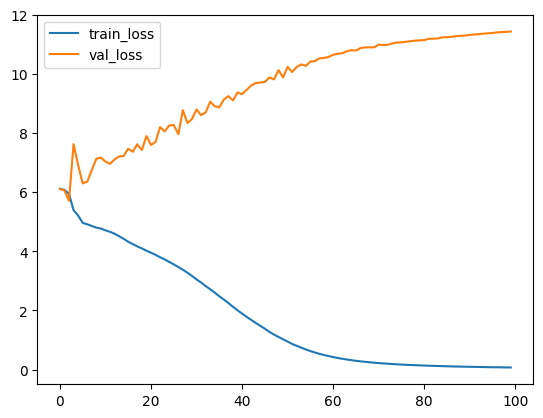

In [ ]:
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

Inference

In [ ]:
# Encoder Model
encoder_model = Model(
    encoder_inputs_ph,
    encoder_states
)

In [ ]:
# Decoder Model (1-step)
decoder_state_input_h = Input(shape=(LATENT_DIM,))
decoder_state_input_c = Input(shape=(LATENT_DIM,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_input_single = Input(shape=(1,))
dec_emb_single = decoder_embedding_layer(decoder_input_single)

decoder_outputs, h, c = decoder_lstm(
    dec_emb_single,
    initial_state=decoder_states_inputs
)

decoder_outputs = decoder_dense(decoder_outputs)

decoder_model = Model(
    [decoder_input_single] + decoder_states_inputs,
    [decoder_outputs, h, c]
)

In [ ]:
# Decoding Function
def decode_sequence(input_seq):
    states = encoder_model.predict(input_seq)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_out["<sos>"]

    eos = word2idx_out["<eos>"]
    output_sentence = []

    for _ in range(max_len_decoder):
        preds, h, c = decoder_model.predict([target_seq] + states)
        idx = np.argmax(preds[0, 0, :])

        if idx == eos:
            break

        if idx > 0:
            output_sentence.append(idx2word_out[idx])

        target_seq[0, 0] = idx
        states = [h, c]

    return " ".join(output_sentence)

In [ ]:
# Test Translations
while True:
    i = np.random.randint(len(input_texts))
    input_seq = encoder_inputs[i:i+1]

    print("English :", input_texts[i])
    print("Telugu:", decode_sequence(input_seq))

    if input("Continue? [Y/n]: ").lower().startswith("n"):
        break

English : He has two pencils. One is long and the other one is short.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Telugu: టామ్ మరియు నేను తరచుగా బస్సులో ముచ్చటిస్తుంటాము.
Continue? [Y/n]: n


### Bidirectional LSTM

Encoder (Bidirectional LSTM)

In [ ]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Encoder
encoder_inputs_ph = Input(shape=(max_len_encoder,))

enc_emb = Embedding(
    input_dim=len(word2idx_in) + 1,
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)(encoder_inputs_ph)

# Bidirectional LSTM
encoder_bilstm = Bidirectional(
    LSTM(LATENT_DIM, return_state=True)
)

_, forward_h, forward_c, backward_h, backward_c = encoder_bilstm(enc_emb)

# Concatenate forward + backward states
state_h = tf.keras.layers.Concatenate()([forward_h, backward_h])
state_c = tf.keras.layers.Concatenate()([forward_c, backward_c])

encoder_states = [state_h, state_c]

Decoder (Standard LSTM)

In [ ]:
decoder_inputs_ph = Input(shape=(max_len_decoder,))

decoder_embedding_layer = Embedding(
    input_dim=num_words_out,
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)

dec_emb = decoder_embedding_layer(decoder_inputs_ph)

decoder_lstm = LSTM(
    LATENT_DIM * 2,        # IMPORTANT
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=encoder_states
)

decoder_dense = Dense(num_words_out, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)

In [ ]:
model = Model(
    [encoder_inputs_ph, decoder_inputs_ph],
    decoder_outputs
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 13, 128)   │     47,744 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 13)        │          0 │ input_layer_5[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ [(None, 512),     │    788,480 │ embedding_2[0][0… │
│ (Bidirectional)     │ (None, 256),      │            │ not_equal_3[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 11, 128)   │     58,240 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 512)       │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ [(None, 11, 512), │  1,312,768 │ embedding_3[0][0… │
│                     │ (None, 512),      │            │ concatenate[0][0… │
│                     │ (None, 512)]      │            │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 11, 455)   │    233,415 │ lstm_3[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,440,647 (9.31 MB)

 Trainable params: 2,440,647 (9.31 MB)

 Non-trainable params: 0 (0.00 B)

Training

In [ ]:
history = model.fit(
    [encoder_inputs, decoder_inputs],
    decoder_targets[..., np.newaxis],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 642ms/step - accuracy: 0.0489 - loss: 6.1131 - val_accuracy: 0.0909 - val_loss: 6.0838
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 547ms/step - accuracy: 0.0909 - loss: 6.0135 - val_accuracy: 0.0909 - val_loss: 5.6140
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 309ms/step - accuracy: 0.0909 - loss: 5.4402 - val_accuracy: 0.0909 - val_loss: 7.7759
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - accuracy: 0.0909 - loss: 5.2391 - val_accuracy: 0.0909 - val_loss: 5.9562
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step - accuracy: 0.0909 - loss: 5.0095 - val_accuracy: 0.0909 - val_loss: 6.1017
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - accuracy: 0.0909 - loss: 4.9018 - val_accuracy: 0.0909 - val_loss: 6.7979
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 309ms/step - accuracy: 0.0909 - loss: 4.8243 - val_accuracy: 0.0909 - val_loss: 7.0210
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 320ms/step - accuracy: 0.0909 - loss: 4.7695 - val_accuracy: 0.0909 - v

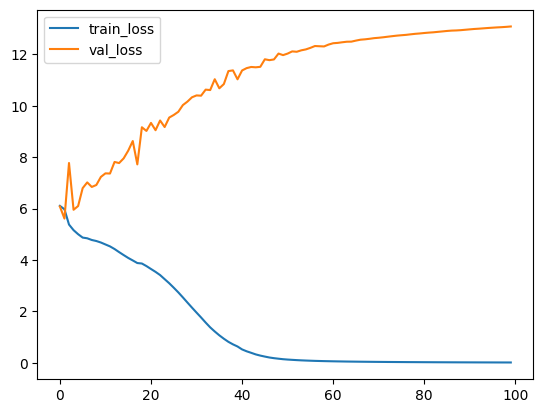

In [ ]:
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

Inference

In [ ]:
# Encoder
encoder_model = Model(
    encoder_inputs_ph,
    encoder_states
)

In [ ]:
# Decoder (1-step inference model)
decoder_state_input_h = Input(shape=(LATENT_DIM * 2,))
decoder_state_input_c = Input(shape=(LATENT_DIM * 2,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_input_single = Input(shape=(1,))
dec_emb_single = decoder_embedding_layer(decoder_input_single)

decoder_outputs, h, c = decoder_lstm(
    dec_emb_single,
    initial_state=decoder_states_inputs
)

decoder_outputs = decoder_dense(decoder_outputs)

decoder_model = Model(
    [decoder_input_single] + decoder_states_inputs,
    [decoder_outputs, h, c]
)

In [ ]:
def decode_sequence(input_seq):
    states = encoder_model.predict(input_seq)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_out["<sos>"]

    eos = word2idx_out["<eos>"]
    output_sentence = []

    for _ in range(max_len_decoder):
        preds, h, c = decoder_model.predict([target_seq] + states)
        idx = np.argmax(preds[0, 0, :])

        if idx == eos:
            break

        if idx > 0:
            output_sentence.append(idx2word_out[idx])

        target_seq[0, 0] = idx
        states = [h, c]

    return " ".join(output_sentence)

In [ ]:
input_texts

['Wonderful!',
 'Definitely!',
 'He hung up.',
 'I ran home.',
 'Who are we?',
 'Are you mad?',
 "He's my son.",
 'He touched me.',
 'My head hurts.',
 'I drank coffee.',
 'Congratulations!',
 'How tall is she?',
 "They're animals.",
 'Can you see that?',
 'I began to speak.',
 'I dislike coffee.',
 "I'm hungry again.",
 "I don't accept it.",
 "They're policemen.",
 "What's in the box?",
 'Which is your pen?',
 'Are you feeling OK?',
 'Help came too late.',
 'How are you coming?',
 'I do make mistakes.',
 "It wasn't my fault.",
 "It's very valuable.",
 "She's not a doctor.",
 'We want to hear it.',
 'What will you have?',
 'Where was your son?',
 'More coffee, please.',
 'Tom was very scared.',
 'What are you saying?',
 'You seem very happy.',
 "I don't know who won.",
 "I'll be very careful.",
 "I've thought of that.",
 'She sat on the bench.',
 'What else can I lose?',
 'Are you two musicians?',
 "I don't need anything.",
 'I heard the bell ring.',
 'I heard you were sick.',
 'I sugg

In [ ]:
while True:
    i = np.random.randint(len(input_texts))
    input_seq = encoder_inputs[i:i+1]

    print("English :", input_texts[i])
    print("Telugu :", decode_sequence(input_seq))

    if input("Continue? [Y/n]: ").lower().startswith("n"):
        break

English : I should've been able to do that by myself.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Telugu : వాళ్ళు ఎక్కడ చెయ్యడానికి నాకు నాకు
Continue? [Y/n]: n


## Attention

In the Attention-based NMT model, **all the encoder states are taken and, for each decoder state, the weights of the encoder’ states are varied according to their perceived importance.** The weighted average of this information provides us with the new context vector at each timestep of the decoder

### Motivation

The main issue with standard seq2seq models is that the **encoder compresses the entire input sentence into a single fixed-length vector**.
- As sentences grow longer, this vector struggles to capture all information, causing the model to forget parts of the input and degrading translation performance. **This hidden vector thus becomes a bottleneck.**

But humans, however, **do not treat all words equally when interpreting a sentence—we assign different importance to words depending on context.**
- In translating “She gave him a book,” the word following “gave” depends more on “him” than “She” — since the indirect object informs how the verb might be expressed in some languages.
- For “I asked them to stay,” the translation of “asked” is influenced more by “them” (the person being asked) than by “I.”

**Attention addresses this by allowing the decoder, at each step, to focus on relevant parts of the input sequence**, dynamically assigning importance to different words.
- This mechanism guides the **decoder to use the most significant information from the encoder** for each generated word, improving translation quality, especially for longer sentences.

### How to assign importance to different words in encoder?

In traditional seq2seq models, the context vector is fixed as the encoder’s final hidden state, creating a bottleneck.
-  Attention overcomes this by **computing a weighted average of all encoder states at each timestep**, effectively acting as an **interpreter between encoder and decoder**.

To assign importance to different words, the model **uses all encoder hidden states instead of just the last one**.
- At each decoder timestep, the **decoder’s hidden state interacts with all encoder states, producing a weighted sum that forms a dynamic context vector.**
- This allows each decoder step to focus on the most relevant parts of the input for predicting the next word.


This mechanism mimics how humans focus on important information while ignoring irrelevant parts. In practice, **the decoder receives two inputs at each step:**
- the previous output and
- the attention-derived context vector, generating better translations until the  token is reached.

### Attention Mechanism

#### Limitation of the Traditional Encoder-Decoder

In a standard seq2seq NMT model:
- The encoder processes the input sequence $X = (x_1, x_2, ..., x_n)$ and produces hidden states $(h_1, h_2, ..., h_n)$.
- The decoder receives only a single context vector, typically the last hidden state $h_n$, as input to generate all output tokens $Y = (y_1, y_2, ..., y_m)$.

**Problem:**
As the input sequence length grows, it is difficult for a single vector h_n to capture all relevant information. **This creates a bottleneck**, leading to poorer translation for long sentences.

#### Idea of Attention

The attention mechanism allows the **decoder to look at all encoder hidden states instead of just the last one.** This produces a dynamic context vector $C_i$ for every decoder timestep i, based on the previously generated decoder state $h_{i-1}$.

Mathematically:
$$
C_i = \sum_{j=1}^{n} \alpha_{ij} h_j
$$
Where:
- $h_j$ = hidden state of encoder at timestep j
- $\alpha_{ij}$ = attention weight for encoder hidden state $h_j$ at decoder timestep i

#### Calculating Attention Weights

The attention weight $\alpha_{ij}$ measures how important the encoder hidden state $h_j$ is for producing the i-th output:
1. Compute a score $e_{ij}$ between the decoder’s previous hidden state $h_{i-1}$ and the encoder hidden state $h_j$:
$$
e_{ij} = a(h_{i-1}, h_j)
$$
- $a(\cdot)$ is a scoring function (can be a small feedforward network, dot product, or other similarity measure).
- A simple form: dot product:
$$
e_{ij} = h_{i-1}^\top h_j
$$
2. Normalize the scores across all encoder states using softmax to get attention weights:
$$
\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k=1}^{n} \exp(e_{ik})}
$$
- $\alpha_{ij} \in [0,1], and \sum_{j=1}^{n} \alpha_{ij} = 1$
- This ensures that the attention weights form a probability distribution over all encoder hidden states.

#### Computing the Context Vector

Once we have attention weights $\alpha_{ij}$, we compute the context vector $C_i$ for the current decoder timestep i as the weighted sum of all encoder hidden states:
$$
C_i = \sum_{j=1}^{n} \alpha_{ij} h_j
$$
- $C_i$ dynamically changes at each decoder timestep.
- It represents the relevant contextual information from the entire input sequence for predicting the next output token $y_i$.

#### Combining Context Vector and Decoder State

After computing $C_i$, we concatenate it with the decoder’s previous hidden state $h_{i-1}$ and pass this combined information into the decoder RNN along with the previous predicted token:
$$
\tilde{h}_i = \text{RNN}([y_{i-1}, C_i], h_{i-1})
$$
- This allows the decoder to selectively focus on different parts of the input for each output token.
- The context vector C_i acts as an interpreter between the encoder and decoder.

- Attention is a technique to compute which encoder state to focus on and how much, given a decoder query.
- Formally, given a set of vector values $\{h_1, h_2, ..., h_n\}$ and a query vector $h_{i-1}$, the attention function computes a weighted sum of the values:
$$
C_i = \sum_{j=1}^{n} \alpha_{ij} h_j
$$
- This weighted sum (the context vector) is a selective summary of the input information tailored to the current decoding step.
- The decoder then uses $C_i$ along with its previous state and previous prediction to generate the next word.

### Types of Attention Mechanisms

In an attention mechanism, the **scoring function** determines how much importance a decoder state should give to each encoder state. There are several commonly used scoring functions:

#### Dot Product Attention

$$
   e_{ij} = h_i^\top h_j
$$
* Computes the similarity between the decoder state $(h_i)$ and encoder state $(h_j)$ using a simple dot product.
* Simple and computationally efficient, but may be less expressive for complex relationships.

#### Multiplicative (or General) Attention

$$
   e_{ij} = h_i^\top W h_j
$$

* Introduces a weight matrix $(W)$ to learn a linear transformation of the encoder state before computing similarity.
* More flexible than dot-product attention, allowing the model to learn interactions between encoder and decoder states.

#### Additive (Bahdanau) Attention

$$
   e_{ij} = V^\top \tanh(W_1 h_i + W_2 h_j)
$$

* Uses separate weight matrices $(W_1)$ and $(W_2)$ applied to the decoder and encoder states, respectively.
* A **tanh** activation introduces a non-linear mapping.
* The resulting vector is then converted to a scalar score via a learnable vector $(V)$.
* Most widely used in NMT (Bahdanau et al., 2015) due to its ability to model complex relationships.

All attention scoring functions are **differentiable**, allowing the model to be trained end-to-end using backpropagation.

The attention mechanism **learns to assign weights** to different encoder states based on the decoder query automatically.

For most neural machine translation implementations, **Bahdanau’s additive attention** is preferred and commonly used.

## Neural Machine Translation with Attention: Step-by-Step Process

### 1. Encoder

   * The encoder reads the input sequence (e.g., a sentence in English) and generates a sequence of hidden states for each timestep:
$$
     (h_1, h_2, \dots, h_n)
$$
   * Unlike the traditional encoder-decoder model, we **retain all encoder outputs** instead of summarizing them into a single context vector.

#### 2. Attention Model

   * At each decoding step (i), the attention model computes a **context vector** $(C_i)$ based on:

     * **Query:** the decoder’s previous hidden state $(h_{i-1})$
     * **Values:** the encoder outputs $(h_1, h_2, \dots, h_n)$
   * The context vector is computed as a **weighted sum** of encoder outputs:
$$
     C_i = \sum_{j=1}^{n} \alpha_{ij} h_j
$$
     - where $\alpha_{ij}$ are the attention weigh(importance ot f encoder state $h_j$ for generating the (i)-th target word).

#### 3. Decoder Input

   * The **context vector $C_i$** is concatenated with the embedding of the previous target word (or <start> token for the first step).
   * This concatenated vector is fed into the decoder RNN (GRU/LSTM) to generate the hidden state $h_i$ for the current timestep.

#### 4. Output Generation

   * The decoder output $h_i$ passes through a **dense layer** with softmax activation to produce a probability distribution over the vocabulary.
   * The word with the **highest probability** is selected as the predicted word for timestep (i).

#### 5. Iterative Decoding

   * For the next timestep:
     * The decoder’s hidden state $h_i$ becomes the **new query** for the attention model.
     * A new context vector $C_{i+1}$ is computed using all encoder outputs and $s_i$.
     * The predicted word from the previous step is fed to the decoder along with the updated context vector.
   * This process continues **until the <end> token** is generated, signaling the completion of translation.

### Luong Dot Product Attention

The objective is to show how Luong (dot‑product) attention is computed over encoder states using decoder states.

- **Input**: encoder states `E`, decoder states `D`.
- **Dot step**: compute similarity scores $D \cdot E$ → `dot_product`.
- **Softmax**: turn scores into attention weights across encoder positions → `score`.
- **Weighted sum**: use weights to combine encoder states → `value` (context).
- **Concat**: merge context with decoder state → `output` (attentional hidden state).

In [ ]:
from tensorflow.keras.layers import Dot, Activation, Concatenate
import numpy as np

# Set a seed so results are reproducible
np.random.seed(42)

In [ ]:
# Random encoder hidden states: (batch_size=1, time_steps=4, hidden_dim=3)
E = np.random.rand(1, 4, 3).round(3)
E

array([[[0.023, 0.151, 0.801],
        [0.937, 0.459, 0.077],
        [0.273, 0.292, 0.758],
        [0.593, 0.876, 0.742]]])

In [ ]:
# Random decoder hidden states: (batch_size=1, time_steps=4, hidden_dim=3)
D = np.random.rand(1, 4, 3).round(3)
D

array([[[0.536, 0.693, 0.411],
        [0.448, 0.075, 0.255],
        [0.979, 0.407, 0.615],
        [0.9  , 0.379, 0.992]]])

- Shape explanation: both `E` and `D` are of shape `(batch_size=1, time_steps=4, hidden_dim=3)`.  
- You can think of:
  - `E[t]` = encoder hidden state at time step `t` (source sequence).
  - `D[t]` = decoder hidden state at time step `t` (target sequence).

Luong attention uses the **decoder** hidden state to attend over all **encoder** hidden states at each time step.

#### Defining the attention layer

In [ ]:
def AttentionLayer(d, e):
    # 1) Alignment scores (dot products between decoder and encoder states)
    #    Dot along the feature dimension: (batch, Td, H) • (batch, Te, H) -> (batch, Td, Te)
    dot_product = Dot(axes=(2, 2))([d, e])

    # 2) Softmax over encoder time dimension -> attention weights
    #    For each decoder time step, this is a probability distribution over encoder steps.
    score = Activation('softmax')(dot_product)

    # 3) Weighted sum of encoder states using attention weights
    #    (batch, Td, Te) • (batch, Te, H) -> (batch, Td, H)
    value = Dot(axes=(2, 1))([score, e])

    # 4) Concatenate context vector (value) with decoder hidden state
    #    (batch, Td, H) concat (batch, Td, H) -> (batch, Td, 2H)
    output = Concatenate()([value, d])

    return dot_product, score, value, output

- **`dot_product`**:  
  For each decoder time step $ t_d $ and encoder time step $ t_e $, compute  
  $\text{score}(t_d, t_e) = D_{t_d} \cdot E_{t_e}$.  
  This is Luong’s dot‑product scoring.

- **`score`** (attention weights):  
  Apply softmax over encoder steps so that for each decoder step, the scores over all encoder positions sum to 1. This gives attention weights.

- **`value`** (context vectors):  
  For each decoder step, take a weighted sum of encoder states using those attention weights. This is the context vector.

- **`output`** (attentional hidden state):  
  Concatenate the decoder state and the context vector: $[ \text{context}; D ]$. This is what many seq2seq models feed into the next layer or prediction layer.

In [ ]:
d, s, v, o = AttentionLayer(D, E)

print("\nDot-product (D, E):")
print(np.round(d, 3))      # raw alignment scores

print("\nScore:")
print(np.round(s, 3))      # attention weights (after softmax)

print("\nAttention values (D, E):")
print(np.round(v, 3))      # context vectors (weighted sum of encoder states)

print("\nAttentional hidden states:")
print(np.round(o, 3))      # [context ; decoder_state]


Dot-product (D, E):
[[[0.446 0.852 0.66  1.23 ]
  [0.226 0.474 0.337 0.521]
  [0.577 1.151 0.852 1.393]
  [0.873 1.094 1.108 1.602]]]

Score:
[[[0.169 0.253 0.209 0.369]
  [0.211 0.27  0.236 0.283]
  [0.157 0.279 0.207 0.356]
  [0.179 0.223 0.227 0.371]]]

Attention values (D, E):
[[[0.517 0.526 0.587]
  [0.49  0.473 0.579]
  [0.533 0.524 0.569]
  [0.495 0.521 0.608]]]

Attentional hidden states:
[[[0.517 0.526 0.587 0.536 0.693 0.411]
  [0.49  0.473 0.579 0.448 0.075 0.255]
  [0.533 0.524 0.569 0.979 0.407 0.615]
  [0.495 0.521 0.608 0.9   0.379 0.992]]]


In [ ]:
np.array(s).sum(axis = 1)

array([[0.71582437, 1.0260835 , 0.8785045 , 1.3795875 ]], dtype=float32)

In [ ]:
np.array(s).sum(axis = 2)

array([[1., 1., 1., 1.]], dtype=float32)

- `d`: shape `(1, 4, 4)`  
  - For each of the 4 decoder time steps, you get 4 scores (one per encoder time step).

- `s`: shape `(1, 4, 4)`  
  - Same shape as `d`, but rows are normalized by softmax -> probabilities.

- `v`: shape `(1, 4, 3)`  
  - For each decoder step, a 3‑dim context vector (same feature size as encoder hidden state).

- `o`: shape `(1, 4, 6)`  
  - Concatenation of `v` (3) and `D` (3) → 6‑dim per time step.

#### Verification of the attention values

In [ ]:
# verification of the first row of attention value

# s[0,0,:] is the attention weights for decoder time step 0
# E[0,i,:] is encoder state at time step i

v1 = np.round(E[0,0,:] * s[0,0,0], 3)  # weight * encoder_step_0
v2 = np.round(E[0,1,:] * s[0,0,1], 3)  # weight * encoder_step_1
v3 = np.round(E[0,2,:] * s[0,0,2], 3)  # weight * encoder_step_2
v4 = np.round(E[0,3,:] * s[0,0,3], 3)  # weight * encoder_step_3

v = np.array([v1, v2, v3, v4])

# Sum over encoder steps to get the final context vector for decoder step 0
np.round(np.sum(v, axis=0), 2)

array([0.52, 0.53, 0.59], dtype=float32)

- `s[0,0,0]`, `s[0,0,1]`, `s[0,0,2]`, `s[0,0,3]` are the 4 attention weights (probabilities) for decoder step 0.
- Each `vi` is “encoder_state_i * its_weight”.
- Summing them along axis 0 gives the context vector for decoder time step 0.  
- This sum should match `v[0,0,:]` (the first row in the attention values printed above), up to rounding.

### Attention Layer

In [ ]:
def AttentionLayer(d, e):
    dot_product = Dot(axes=(2, 2))([d, e])
    score = Activation('softmax')(dot_product)
    value = Dot(axes=(2, 1))([score, e])
    return Concatenate()([value, d])

In [ ]:
# Random encoder hidden states: (batch_size=1, time_steps=4, hidden_dim=3)
print(AttentionLayer(D, E))

tf.Tensor(
[[[0.5170625  0.5261621  0.5869914  0.536      0.693      0.411     ]
  [0.49030823 0.4727471  0.5785225  0.448      0.075      0.255     ]
  [0.5331813  0.52439785 0.56873    0.979      0.407      0.615     ]
  [0.49527928 0.5207968  0.6077003  0.9        0.379      0.992     ]]], shape=(1, 4, 6), dtype=float32)


### Luong dot product Attention

In [ ]:
# ---------- Encoder ----------
encoder_inputs_ph = Input(shape=(max_len_encoder,))
enc_emb = Embedding(
    input_dim=len(word2idx_in) + 1,
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)(encoder_inputs_ph)

# return_sequences=True so we keep all encoder hidden states
encoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True
)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

In [ ]:
# ---------- Decoder ----------
decoder_inputs_ph = Input(shape=(max_len_decoder,))
decoder_embedding_layer = Embedding(
    input_dim=num_words_out,
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)
dec_emb = decoder_embedding_layer(decoder_inputs_ph)

decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=encoder_states
)

# ---------- Luong dot-product attention ----------
# 1) score = decoder_outputs · encoder_outputs^T
attention_scores = Dot(axes=[2, 2])([decoder_outputs, encoder_outputs])  # (batch, T_dec, T_enc)

# 2) attention weights (softmax over encoder time axis)
attention_weights = Activation('softmax', name='attention_weights')(attention_scores)

# 3) context = sum_j alpha_ij * encoder_outputs_j
context = Dot(axes=[2, 1])([attention_weights, encoder_outputs])  # (batch, T_dec, LATENT_DIM)

# 4) concat context with decoder_outputs
decoder_combined_context = Concatenate(axis=-1)([decoder_outputs, context])  # (batch, T_dec, 2*LATENT_DIM)

# ---------- Final output ----------
decoder_dense = Dense(num_words_out, activation="softmax")
decoder_outputs_final = decoder_dense(decoder_combined_context)

In [ ]:
model = Model(
    [encoder_inputs_ph, decoder_inputs_ph],
    decoder_outputs_final
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 13, 128)   │     47,744 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_6         │ (None, 13)        │          0 │ input_layer_10[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 11, 128)   │     58,240 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 13, 256), │    394,240 │ embedding_4[0][0… │
│                     │ (None, 256),      │            │ not_equal_6[0][0] │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, 11, 256), │    394,240 │ embedding_5[0][0… │
│                     │ (None, 256),      │            │ lstm_4[0][1],     │
│                     │ (None, 256)]      │            │ lstm_4[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 11, 13)    │          0 │ lstm_5[0][0],     │
│                     │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 11, 13)    │          0 │ dot[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 11, 256)   │          0 │ attention_weight… │
│                     │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 11, 512)   │          0 │ lstm_5[0][0],     │
│ (Concatenate)       │                   │            │ dot_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 11, 455)   │    233,415 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,127,879 (4.30 MB)

 Trainable params: 1,127,879 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ---------- Training ----------
history = model.fit(
    [encoder_inputs, decoder_inputs],
    decoder_targets[..., np.newaxis],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 402ms/step - accuracy: 0.2928 - loss: 6.0884 - val_accuracy: 0.3754 - val_loss: 5.9825
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - accuracy: 0.5483 - loss: 5.7611 - val_accuracy: 0.3754 - val_loss: 5.3560
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.5404 - loss: 4.4398 - val_accuracy: 0.3754 - val_loss: 4.0748
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.5558 - loss: 2.8178 - val_accuracy: 0.3754 - val_loss: 5.8716
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.5606 - loss: 2.8268 - val_accuracy: 0.3754 - val_loss: 4.9865
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.5496 - loss: 2.6334 - val_accuracy: 0.3754 - val_loss: 3.9852
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.5522 - loss: 2.4556 - val_accuracy: 0.3754 - val_loss: 3.7626
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.5448 - loss: 2.4961 - val_accuracy: 0.3754 - v

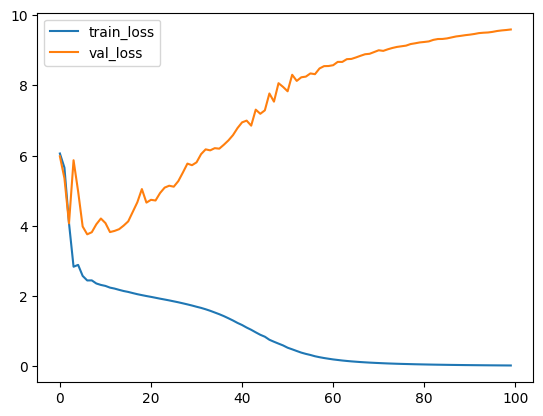

In [ ]:
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

Inference

In [ ]:
# ---------- Encoder Inference Model ----------
encoder_model = Model(
    encoder_inputs_ph,
    [encoder_outputs, state_h, state_c]  # return all encoder outputs + final states
)

In [ ]:
# ---------- Decoder Inference Model ----------
decoder_state_input_h = Input(shape=(LATENT_DIM,), name="dec_h_in")
decoder_state_input_c = Input(shape=(LATENT_DIM,), name="dec_c_in")
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# encoder outputs (constant memory) for attention at inference
encoder_outputs_inf = Input(shape=(max_len_encoder, LATENT_DIM), name="enc_outs_in")

decoder_input_single = Input(shape=(1,), name="dec_word_in")
dec_emb_single = decoder_embedding_layer(decoder_input_single)

decoder_outputs_single, h, c = decoder_lstm(
    dec_emb_single,
    initial_state=decoder_states_inputs
)  # (batch=1, 1, LATENT_DIM)

# attention at inference
attention_scores_inf = Dot(axes=[2, 2])([decoder_outputs_single, encoder_outputs_inf])  # (1, 1, T_enc)
attention_weights_inf = Activation('softmax')(attention_scores_inf)
context_inf = Dot(axes=[2, 1])([attention_weights_inf, encoder_outputs_inf])  # (1, 1, LATENT_DIM)

decoder_combined_context_inf = Concatenate(axis=-1)([decoder_outputs_single, context_inf])  # (1, 1, 2*LATENT_DIM)

decoder_outputs_single_final = decoder_dense(decoder_combined_context_inf)

decoder_model = Model(
    [decoder_input_single, encoder_outputs_inf] + decoder_states_inputs,
    [decoder_outputs_single_final, h, c]
)


In [ ]:
def decode_sequence(input_seq):
    # Encode the input as encoder_outputs + final states
    encoder_outs, state_h, state_c = encoder_model.predict(input_seq)
    states = [state_h, state_c]

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_out["<sos>"]

    eos = word2idx_out["<eos>"]
    output_sentence = []

    for _ in range(max_len_decoder):
        preds, h, c = decoder_model.predict(
            [target_seq, encoder_outs] + states
        )
        idx = np.argmax(preds[0, 0, :])

        if idx == eos:
            break

        if idx > 0:
            output_sentence.append(idx2word_out[idx])

        target_seq[0, 0] = idx
        states = [h, c]

    return " ".join(output_sentence)


In [ ]:
# Test Translations
while True:
    i = np.random.randint(len(input_texts))
    input_seq = encoder_inputs[i:i+1]

    print("English :", input_texts[i])
    print("Telugu:", decode_sequence(input_seq))

    if input("Continue? [Y/n]: ").lower().startswith("n"):
        break

English : My sister is crazy about tennis.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Telugu: మా అక్కకి టెన్నిసంటే పిచ్చి
Continue? [Y/n]: Y
English : He has two pencils. One is long and the other one is short.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Telugu: అతడు తన చివరికి అంటిన సంపాదించాడు. కడిగేసాడు
Continue? [Y/n]: Y
English : Tom thought he might not be permitted to do that by himself.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━

Input Feeding Attention

In [ ]:
# ---------- Encoder ----------
encoder_inputs_ph = Input(shape=(max_len_encoder,))
enc_emb = Embedding(
    input_dim=len(word2idx_in) + 1,
    output_dim=EMBEDDING_DIM,
    mask_zero=False
)(encoder_inputs_ph)
encoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True
)
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

In [ ]:
# ---------- Decoder (base) ----------
decoder_inputs_ph = Input(shape=(max_len_decoder,))
decoder_embedding_layer = Embedding(
    input_dim=num_words_out,
    output_dim=EMBEDDING_DIM,
    mask_zero=False
)
dec_emb = decoder_embedding_layer(decoder_inputs_ph)

decoder_lstm = LSTM(
    LATENT_DIM,
    return_sequences=True,
    return_state=True
)

# standard decoder hidden states (before attention)
decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=encoder_states
)

# ---------- Luong dot-product attention ----------
# scores: (batch, T_dec, T_enc)
attention_scores = Dot(axes=[2, 2])([decoder_outputs, encoder_outputs])

attention_weights = Activation('softmax', name='attention_weights')(attention_scores)

# context: (batch, T_dec, LATENT_DIM)
context = Dot(axes=[2, 1])([attention_weights, encoder_outputs])

# attentional vector (concatenate h_t and c_t)
attn_vector = Concatenate(axis=-1)([decoder_outputs, context])   # (batch, T_dec, 2*LATENT_DIM)

# ---------- Input-feeding projection ----------
# Map attentional vector back to decoder hidden size
attn_fed = TimeDistributed(
    Dense(LATENT_DIM, activation='tanh'),
    name='input_feeding_projection'
)(attn_vector)   # (batch, T_dec, LATENT_DIM)

# Now combine with original decoder outputs: this makes
# the next decoder step aware of previous attention choices
decoder_input_fed = Concatenate(axis=-1)(
    [decoder_outputs, attn_fed]
)  # (batch, T_dec, 2*LATENT_DIM)

# ---------- Final output ----------
decoder_dense = TimeDistributed(Dense(num_words_out, activation="softmax"))
decoder_outputs_final = decoder_dense(decoder_input_fed)

In [ ]:
model = Model(
    [encoder_inputs_ph, decoder_inputs_ph],
    decoder_outputs_final
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_13      │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 13, 128)   │     47,744 │ input_layer_12[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 11, 128)   │     58,240 │ input_layer_13[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ [(None, 13, 256), │    394,240 │ embedding_6[0][0] │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ [(None, 11, 256), │    394,240 │ embedding_7[0][0… │
│                     │ (None, 256),      │            │ lstm_6[0][1],     │
│                     │ (None, 256)]      │            │ lstm_6[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_4 (Dot)         │ (None, 11, 13)    │          0 │ lstm_7[0][0],     │
│                     │                   │            │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 11, 13)    │          0 │ dot_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_5 (Dot)         │ (None, 11, 256)   │          0 │ attention_weight… │
│                     │                   │            │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 11, 512)   │          0 │ lstm_7[0][0],     │
│ (Concatenate)       │                   │            │ dot_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_feeding_proj… │ (None, 11, 256)   │    131,328 │ concatenate_6[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 11, 512)   │          0 │ lstm_7[0][0],     │
│ (Concatenate)       │                   │            │ input_feeding_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 11, 455)   │    233,415 │ concatenate_7[0]… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,259,207 (4.80 MB)

 Trainable params: 1,259,207 (4.80 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ---------- Training ----------
history = model.fit(
    [encoder_inputs, decoder_inputs],
    decoder_targets[..., np.newaxis],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 461ms/step - accuracy: 0.2941 - loss: 6.0250 - val_accuracy: 0.3754 - val_loss: 5.7003
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.5462 - loss: 4.4383 - val_accuracy: 0.3754 - val_loss: 4.3080
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - accuracy: 0.5471 - loss: 3.2099 - val_accuracy: 0.3754 - val_loss: 3.8026
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step - accuracy: 0.5814 - loss: 2.5417 - val_accuracy: 0.4545 - val_loss: 3.7378
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 0.6208 - loss: 2.3611 - val_accuracy: 0.3783 - val_loss: 3.9527
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.5803 - loss: 2.2880 - val_accuracy: 0.3783 - val_loss: 4.0541
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.6003 - loss: 2.2480 - val_accuracy: 0.4399 - val_loss: 3.8146
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.6346 - loss: 2.2218 - val_accuracy: 0.4633 - v

Inference

In [ ]:
# ---------- Encoder Inference Model ----------
# Returns encoder_outputs (for attention) + final states
encoder_model = Model(
    encoder_inputs_ph,
    [encoder_outputs, state_h, state_c]
)

In [ ]:
# States from previous step
decoder_state_input_h = Input(shape=(LATENT_DIM,), name="dec_h_in")
decoder_state_input_c = Input(shape=(LATENT_DIM,), name="dec_c_in")
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# Encoder outputs (fixed memory)
encoder_outputs_inf = Input(
    shape=(max_len_encoder, LATENT_DIM),
    name="enc_outs_in"
)

# Current input token (one step)
decoder_input_single = Input(shape=(1,), name="dec_word_in")
dec_emb_single = decoder_embedding_layer(decoder_input_single)   # (1, 1, EMBEDDING_DIM)

# Run one step of decoder LSTM
decoder_outputs_single, h, c = decoder_lstm(
    dec_emb_single,
    initial_state=decoder_states_inputs
)  # (1, 1, LATENT_DIM)

# ----- Luong attention -----
attention_scores_inf = Dot(axes=[2, 2])(
    [decoder_outputs_single, encoder_outputs_inf]
)  # (1, 1, T_enc)

attention_weights_inf = Activation('softmax', name="attn_weights_inf")(
    attention_scores_inf
)

context_inf = Dot(axes=[2, 1])(
    [attention_weights_inf, encoder_outputs_inf]
)  # (1, 1, LATENT_DIM)

# attentional vector
attn_vector_inf = Concatenate(axis=-1)(
    [decoder_outputs_single, context_inf]
)  # (1, 1, 2*LATENT_DIM)

# same projection as training (must have same layer config)
attn_fed_inf = TimeDistributed(
    Dense(LATENT_DIM, activation='tanh'),
    name='input_feeding_projection_inf'
)(attn_vector_inf)  # (1, 1, LATENT_DIM)

decoder_input_fed_inf = Concatenate(axis=-1)(
    [decoder_outputs_single, attn_fed_inf]
)  # (1, 1, 2*LATENT_DIM)

decoder_outputs_single_final = decoder_dense(decoder_input_fed_inf)  # (1, 1, num_words_out)

decoder_model = Model(
    [decoder_input_single, encoder_outputs_inf] + decoder_states_inputs,
    [decoder_outputs_single_final, h, c]
)

In [ ]:
def decode_sequence(input_seq,
                    encoder_model,
                    decoder_model,
                    word2idx_out,
                    idx2word_out,
                    max_len_decoder):
    # Encode input: get encoder outputs and final states
    encoder_outs, state_h, state_c = encoder_model.predict(input_seq)
    states = [state_h, state_c]

    # Start token
    target_seq = np.zeros((1, 1), dtype="int32")
    target_seq[0, 0] = word2idx_out["<sos>"]

    eos_id = word2idx_out["<eos>"]
    decoded_tokens = []

    for _ in range(max_len_decoder):
        preds, h, c = decoder_model.predict(
            [target_seq, encoder_outs] + states
        )

        idx = np.argmax(preds[0, 0, :])

        if idx == eos_id:
            break

        if idx > 0:
            decoded_tokens.append(idx2word_out.get(idx, ""))

        # Next input is current prediction
        target_seq[0, 0] = idx
        states = [h, c]

    return " ".join(tok for tok in decoded_tokens if tok)

In [ ]:
while True:
    i = np.random.randint(len(input_texts))
    input_seq = encoder_inputs[i:i+1]

    print("Source :", input_texts[i])
    print("Target :", decode_sequence(
        input_seq,
        encoder_model,
        decoder_model,
        word2idx_out,
        idx2word_out,
        max_len_decoder
    ))

    if input("Continue? [Y/n]: ").lower().startswith("n"):
        break

Source : You have no need to be ashamed.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Target : నాకు సహాయం సిద్దంగా నివసిస్తున్నావా? రాకు. రాకు. రాకు. రాకు. రాకు. రాకు. రాకు.
Continue? [Y/n]: Y
Source : I'll let it go this time.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Target : నాకు నాకు ఎక్కడ ఏం ? ?
Continue? [Y/n]: Y
Sour

In [ ]:
def encode_input_sentence(sentence, tokenizer_in, max_len_encoder):
    """
    sentence      : raw English string
    tokenizer_in  : fitted on input_texts
    max_len_encoder: max length used during training
    """
    # Basic normalization (optional, you can customize)
    sentence = sentence.strip()

    # Convert to sequence of word indices
    seq = tokenizer_in.texts_to_sequences([sentence])[0]

    # If completely OOV, seq may be empty; handle that
    if len(seq) == 0:
        # use OOV token explicitly if needed
        seq = [tokenizer_in.word_index.get('<UNK>', 0)]

    # Pad to encoder max length
    enc_input = pad_sequences(
        [seq],
        maxlen=max_len_encoder,
        padding="post"
    )
    return enc_input
print("\nType an English sentence to translate (or 'quit' to exit):")
while True:
    eng_sent = input("> ").strip()
    if eng_sent.lower() in ("quit", "exit", "q"):
        break

    # Encode the raw sentence using the SAME tokenizer and max_len_encoder
    enc_input = encode_input_sentence(eng_sent, tokenizer_in, max_len_encoder)

    # Use your existing decode_sequence + models
    telugu = decode_sequence(enc_input)
    print("Telugu:", telugu)


Type an English sentence to translate (or 'quit' to exit):
> n


TypeError: decode_sequence() missing 5 required positional arguments: 'encoder_model', 'decoder_model', 'word2idx_out', 'idx2word_out', and 'max_len_decoder'

### BLEU Score: Machine Translation Quality Metric

**BLEU (Bilingual Evaluation Understudy)** measures how close a machine-generated translation is to human reference translations using **n-gram overlap**. Score: 0 (bad) → 1 (perfect match).
- Mainly used for text translation, Compares with human-generated
translations
- It is an evaluation metric for automatically evaluating a machine-translated text.
- It is calculated by taking the difference between a predicted text sequence and another human created text sequence of the same source sentence.

Raw precision
```
Candidate:     "the the the the the the the" (7 words)
Refs:   "the cat is on the mat" | "there is a cat on the mat"
Raw:    7/7 = 1.0 (all "the" match!) ✗
```

Modified Unigram Precision or Clipped precision: Credit ≤ max count in any reference
```
Candidate: the the the the the the the.
Reference 1: The cat is on the mat.
Reference 2: There is a cat on the mat.
Modified Unigram Precision= 2/7
"the" appears max(2,1) = 2 times → score 2/7 = 0.29 ✓
```

Bigram Precision

```
Candidate: The cat the cat on the mat.
Reference 1: The cat is on the mat.
Reference 2: There is a cat on the mat.

Bigrams: "the cat"(2), "cat the"(1), "cat on"(1), "on the"(1), "the mat"(1)
Bigrams (Clipped):"the cat"(1), "cat the"(0), "cat on"(1), "on the"(1), "the mat"(1)
Clipped: 1, 0, 1, 1, 1 → sum=4/6 bigrams = 0.67 ✓
```

**Modified n-gram precision on blocks of text:** We first compute the n-gram matches sentence by sentence. Next, we add the clipped n-gram counts for all the candidate sentences and divide by the number of candidate n-grams in the test corpus to compute a modified precision score, $p_n$, for the entire test corpus.

$$ p_n = \frac{\sum_{C \in \{\text{Candidates}\}} \sum_{\text{n-gram} \in C} \text{Count}_{\text{clip}}(\text{n-gram})}{\sum_{C' \in \{\text{Candidates}\}} \sum_{\text{n-gram}' \in C'} \text{Count}(\text{n-gram}')} $$  
where $\text{Count}_{\text{clip}}(w) = \min(\text{Count}(w), \max_{\text{refs}} \text{Count}_{\text{ref}}(w))$

**Brevity Penalty (BP):** Punish short outputs (high precision, low content)  

$$ BP = \begin{cases}
1 & \text{if } c > r \\
\exp(1 - r/c) & \text{if } c \leq r
\end{cases} $$  
c = Candidate length, r = closest reference length (corpus-level).

```
Reference: 6 words, Candidate: 2 words → BP = exp(1-6/2) = exp(-2) ≈ 0.135
```

**BLEU-N (Combined Precisions)**: Geometric mean of 1-N gram precisions (N=4 standard):  


$$ \text{BLEU-N} = BP \cdot \exp\left( \sum_{n=1}^N w_n \log p_n \right) $$  
Uniform weights: $w_n = 1/N$.

```
BLEU-4: exp(¼( log p₁ + log p₂ + log p₃ + log p₄ ))
```

Full BLEU-4 Formula

$$ \text{BLEU} = BP \cdot \exp\left( \frac{1}{4} \sum_{n=1}^4 \log p_n \right) $$

**Example:**

Reference: "Back to the Future premiered 30 years ago"

Candidate: "Back to the Future had premiered 30 years ago"

- Unigram: 8/9 (had is not in Reference)
- Bigram: 6/8
```
Candidate - {'Back to': 1, 'to the': 1, 'the Future': 1, 'Future had': 1, 'had premiered': 1, 'premiered 30': 1, '30 years': 1, 'years ago': 1}

Reference - {'Back to': 1, 'to the': 1, 'the Future': 1, 'Future had': 0, 'had premiered': 0, 'premiered 30': 1, '30 years': 1, 'years ago': 1}
```
- Trigram: 4/7
```
Candidate - {'Back to the': 1, 'to the Future': 1, 'the Future had': 1, 'Future had premiered': 1, 'had premiered 30': 1, 'premiered 30 years': 1, '30 years ago': 1}
Reference - {'Back to the': 1, 'to the Future': 1, 'the Future had': 0, 'Future had premiered': 0, 'had premiered 30': 0, 'premiered 30 years': 1, '30 years ago': 1}

```
- Fourgram: 2/6
```
Candidate - {'Back to the Future': 1, 'to the Future had': 1, 'the Future had premiered': 1, 'Future had premiered 30': 1, 'had premiered 30 years': 1, 'premiered 30 years ago': 1}
Reference - {'Back to the Future': 1, 'to the Future had': 0, 'the Future had premiered': 0, 'Future had premiered 30': 0, 'had premiered 30 years': 0, 'premiered 30 years ago': 1}
```

**Brevity penality**

Candidate length > Reference length

BP: 1

```
BLEU-4: 1 * exp(¼( log(8/9) + log(6/8) + log(4/7) + log(2/6)))
```



In [ ]:
import numpy as np

In [ ]:
1 * np.exp((1/4)*(np.log(8/9) + np.log(6/8) + np.log(4/7) + np.log(2/6)))

np.float64(0.5969491792019646)

In [ ]:
from nltk.translate.bleu_score import sentence_bleu

ref = [['Back','to', 'the', 'Future', 'premiered', '30', 'years', 'ago']]
can  = ['Back','to', 'the', 'Future', 'had', 'premiered', '30', 'years', 'ago']
print(sentence_bleu(ref, can))

0.5969491792019646


### ROUGE

- ROUGE (Recall-Oriented Understudy for Gisting Evaluation) is used mostly for summarization. It measures overlap between generated and reference summaries.
- Measures overlap between generated and reference texts. A higher ROUGE score reflects a better-quality summary.
- ROUGE-1/2/L help diagnose whether your model captures key content and some ordering.  
- Recall-based metric.

Example:
```
Reference (human): It is cold outside.
Candidate output: It is very cold outside.
```

- **Recall (ROUGE-1 recall)**:  
  fraction of reference unigrams that appear in the output.  

ROUGE-1 Recall - 4 (unigram matches)/4 (unigrams in reference) - 1
```
unigram matches - {'It', 'is', 'cold', 'outside'} - 4
unigrams in reference - {'It', 'is', 'cold', 'outside'} - 4
```

ROUGE-2 Recall - 2 (bigram matches)/3 (bigrams in reference) - 0.67
```
bigram matches - {'It is', 'cold outside'} - 2
bigrams in reference - {'It is', 'is cold', 'cold outside'} - 3
```

*ROUGE*-L Recall - 2 (LCS(Cand, Ref))/4 (Unigrams in reference) - 0.5
```
LCS(Cand, Ref) - {'It is', 'cold outside'} - 2
Unigrams in reference - {'It', 'is', 'cold', 'outside'} - 4
```

- **Precision (ROUGE-1 precision)**:  
  fraction of output unigrams that appear in the reference.  

ROUGE-1 Precision - 4 (unigram matches)/5 (unigrams in output) - 0.8
```
unigram matches - {'It', 'is', 'cold', 'outside'} - 4
unigrams in output - {'It', 'is', 'very', 'cold', 'outside'} - 5
```

ROUGE-2 Precision - 2 (bigram matches)/4 (bigrams in output) - 0.5
```
bigram matches - {'It is', 'cold outside'} - 2
bigrams in output - {'It is', 'is very', 'very cold', 'cold outside'} - 4
```

ROUGE-L Precision - 2 (LCS(Cand, Ref))/5 (unigrams in output) - 0.4
```
unigram matches - {'It is', 'cold outside'} - 2
unigrams in output - {'It', 'is', 'very', 'cold', 'outside'} - 5
```

- **F1**: harmonic mean of recall and precision.

In [ ]:
F1 = 2*((0.4*0.5)/(0.4+0.5))
F1

In [ ]:
!pip install evaluate
!pip install rouge_score

In [ ]:
from rouge_score import rouge_scorer
# Create a scorer for ROUGE-1, ROUGE-2, and ROUGE-L
scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

In [ ]:
reference = "It is cold outside"
candidate = "It is very cold outside"

scores = scorer.score(reference, candidate)

print("ROUGE-1:", scores['rouge1'])  # precision, recall, fmeasure
print("ROUGE-2:", scores['rouge2'])
print("ROUGE-L:", scores['rougeL'])

# Access F1 directly
print("ROUGE-1 F1:", scores['rouge1'].fmeasure)
print("ROUGE-L F1:", scores['rougeL'].fmeasure)

In [ ]:
import evaluate

rouge = evaluate.load("rouge")
rouge

In [ ]:
predictions = [
    "It is very cold outside"
]
references = [
    "It is cold outside"
]

results = rouge.compute(
    predictions=predictions,
    references=references,
    rouge_types=['rouge1', 'rouge2', 'rougeL']
)

print(results)  # e.g. {'rouge1': 0.92, 'rouge2': 0.78, 'rougeL': 0.90}

In [ ]:
predictions = [
    "It is very cold outside",
    "The cat was found under the bed",
]
references = [
    "It is cold outside",
    "The cat was under the bed",
]

results = rouge.compute(
    predictions=predictions,
    references=references,
    rouge_types=['rouge1', 'rouge2', 'rougeL'],
    use_aggregator=True  # average over all examples
)

print(results)

**How to Use ROUGE and BLEU in Practice?**

- **ROUGE**  
  - Use for **summarization** and similar tasks (e.g., headline generation).  

  - Compare scores only when:  
    - Same dataset,  
    - Same task,  
    - Same evaluation setup.  

- **BLEU**  
  - Use for **machine translation** (and sometimes image captioning).  
  - BLEU-4 (1–4 gram average) is the most common.  
  - Higher BLEU roughly means closer to human translations, but it is not perfect and should be complemented with human evaluation or more modern metrics.  

- **For LLM fine-tuning**  
  - Use ROUGE for summarization-style tasks.  
  - Use BLEU for translation-style tasks.  
  - Treat them as **quick, low-cost diagnostics** during development, not as the only evidence of “model quality”.  
  - For overall performance, rely on broader **benchmarks** and, when possible, human evaluation.  
